# Improved Result Reporting
- I decided it would be too difficult to actually predict maxima and minima. It is also hard to define these as a baseline.
- Fitting for the next peak on the posterior samples is unreliable.
- This notebook with use GPR17 but make three key changes:
    1) Remove the tranisition ringing by including the training time in the predictions to allow the ringing to die off.
    2) Remove data leakage by choosing model on the validation set. Then retraining with those params on the valid + training and seeing performance on the test.
    3) Only use lookahead windows to report results. This is more reliable than the minima and maxima fitting. 

In [33]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import emcee

from scipy.optimize import minimize
from scipy.special import softmax

import celerite2
from celerite2 import terms

from prettytable import PrettyTable

from scipy.stats import norm

import sys
from pathlib import Path

sys.path.append(str(Path('../..').resolve()))

from helpers.df_ops import prepare_df, split_df, clean_df
from helpers.priors import find_classify_signals, get_priors

def set_params(log_params, k, gp):
    # k = len(log_params) // 3
    params = np.exp(log_params)
    sigmas = params[0:k]
    rhos = params[k:2*k]
    qs = params[2*k::]
    
    gp.kernel = terms.SHOTerm(sigma=sigmas[0], rho=rhos[0], Q=qs[0])
    for k_idx in range(1,k):
        gp.kernel += terms.SHOTerm(sigma=sigmas[k_idx], rho=rhos[k_idx], Q=qs[k_idx])
    return gp

def NLL(log_params, gp, k, y):
    gp = set_params(log_params, k, gp)
    gp.recompute(quiet=True)
    return -gp.log_likelihood(y)

def lnPost(log_params, gp, k, y, initial_guesses, bounds, prior_std=3):
    if np.any(log_params < bounds[:, 0]) or np.any(log_params > bounds[:, 1]):
        return -np.inf
    gp = set_params(log_params, k, gp)
    gp.recompute(quiet=True)
    ll = gp.log_likelihood(y)
    if not np.isfinite(ll):
        return -np.inf
    return ll - 0.5 * np.sum(((np.exp(log_params) - np.exp(initial_guesses)) / prior_std) ** 2)

def plot_trace(sampler, param_names=None):
    samples = sampler.get_chain()  # shape: (n_steps, n_walkers, n_params)
    n_steps, n_walkers, n_params = samples.shape

    if param_names is None:
        param_names = [f"param_{i}" for i in range(n_params)]

    fig, axes = plt.subplots(n_params, 1, figsize=(10, 2.5 * n_params), sharex=True)
    if n_params == 1:
        axes = [axes]

    for i, ax in enumerate(axes):
        ax.plot(np.exp(samples[:, :, i]), color="steelblue", alpha=0.3, lw=0.7)
        ax.set_ylabel(param_names[i])
        ax.yaxis.set_label_coords(-0.1, 0.5)

    axes[-1].set_xlabel("Step")
    axes[0].set_title("MCMC Trace")
    fig.tight_layout()
    plt.show()


In [ ]:
# ---- PARAMS ----
datapath            = r"../../Data/benchmark/HD201091_Mt_wilson_data.txt"
direct_bound_tol    = 0.1
sm2016_bound_tol    = 0.2
mean_bound_tol      = 1
add_prefix          = False
relative            = True
train_split         = 0.6
valid_split         = 0.15 
star_type           = "G"
star_name           = "HD201091"
error_percent       = 2.5
sigma_upper_mult    = 5.0
q_bounds_in         = [1, 5]  # THIS HAS BEEN CHANGED
verbose             = True
plot                = True
loop_verbose        = True
loop_plot           = True
loop_savefigs       = False
sampler_plot        = True
result_plot_cadence = 50
result_plot_extra   = 1000
require_mid         = True
total_sample_count  = 5000
plot_every          = 200
subsample           = 2000
n_walkers           = 32
valid_metric        = "CRPS"
SEED                = 1701

Removed 0 datapoints which had NaN.
Removed 10 datapoints that were deemed ourliers by tolerance in sind of 4 times MAD.


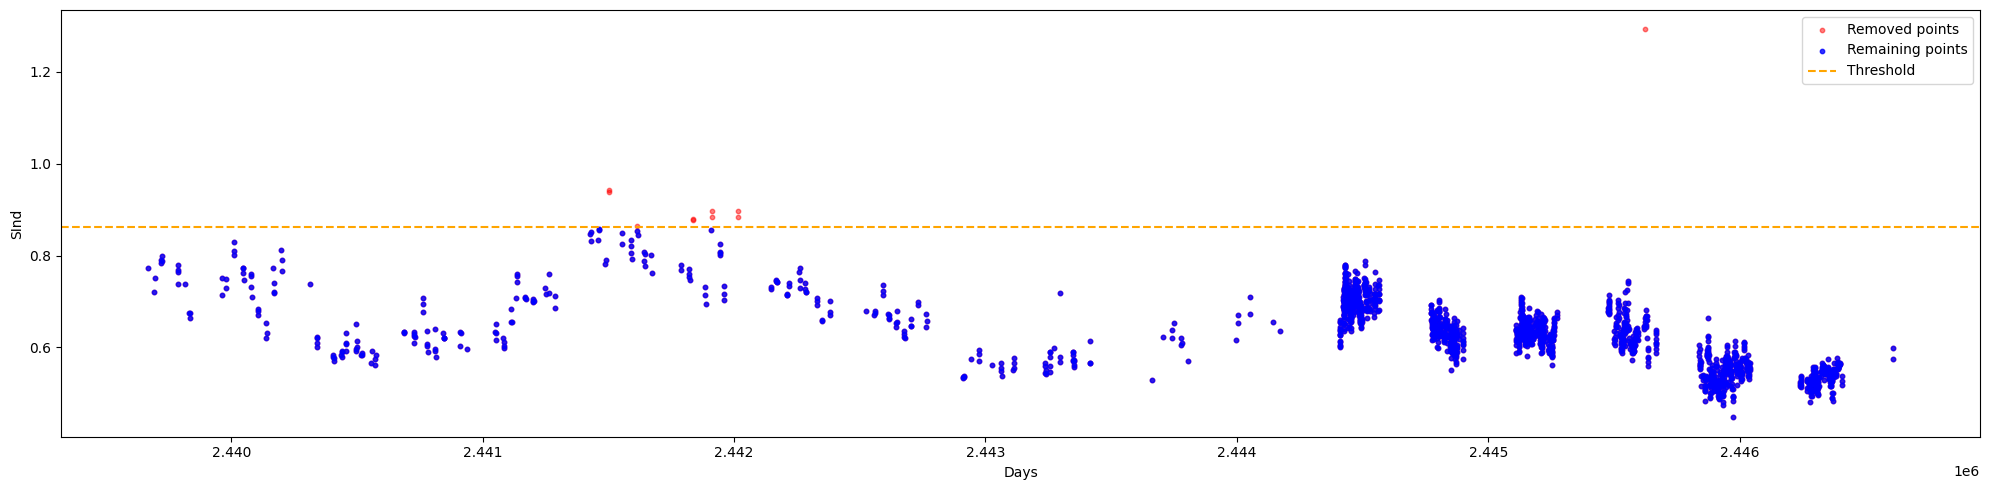

In [35]:
#-----Data Handling-----------

# Import
raw_df   = pd.read_csv(datapath, sep=r'\s+', skip_blank_lines=True)
data_df  = prepare_df(raw_df, add_prefix=add_prefix, relative=relative)

#Split
dirty_train_df, dirty_valid_df, test_df = split_df(data_df, train_split=train_split, valid_split=valid_split)

# Clean
train_df, valid_df, MAD = clean_df(dirty_train_df, dirty_valid_df, tol=4, verbose=verbose, plot=plot)

In iteration 0, period at 2734.70 days was accepted.
In iteration 1, period at 15173.63 days was accepted.
Peak at period 1374.33 days was identified to be an alias of 2734.70 days at mult 0.50 by tolerance 0.01.
In iteration 2, period at 495.77 days was accepted.
Peak at period 1361.92 days was identified to be an alias of 2734.70 days at mult 0.50 by tolerance 0.00.
Peak at period 1956.51 days was identified to be an alias of 495.77 days at mult 4.00 by tolerance 0.01.
In iteration 3, period at 289.91 days was accepted.
Peak at period 1975.49 days was identified to be an alias of 495.77 days at mult 4.00 by tolerance 0.00.
Peak at period 115.81 days was identified to be a window of 121.75 days by tolerance 0.05.
In iteration 4, period at 38.79 days was accepted.
Peak at period 1976.59 days was identified to be an alias of 495.77 days at mult 4.00 by tolerance 0.00.
Peak at period 115.81 days was identified to be an alias of 38.79 days at mult 3.00 by tolerance 0.00.
In iteration 5, p

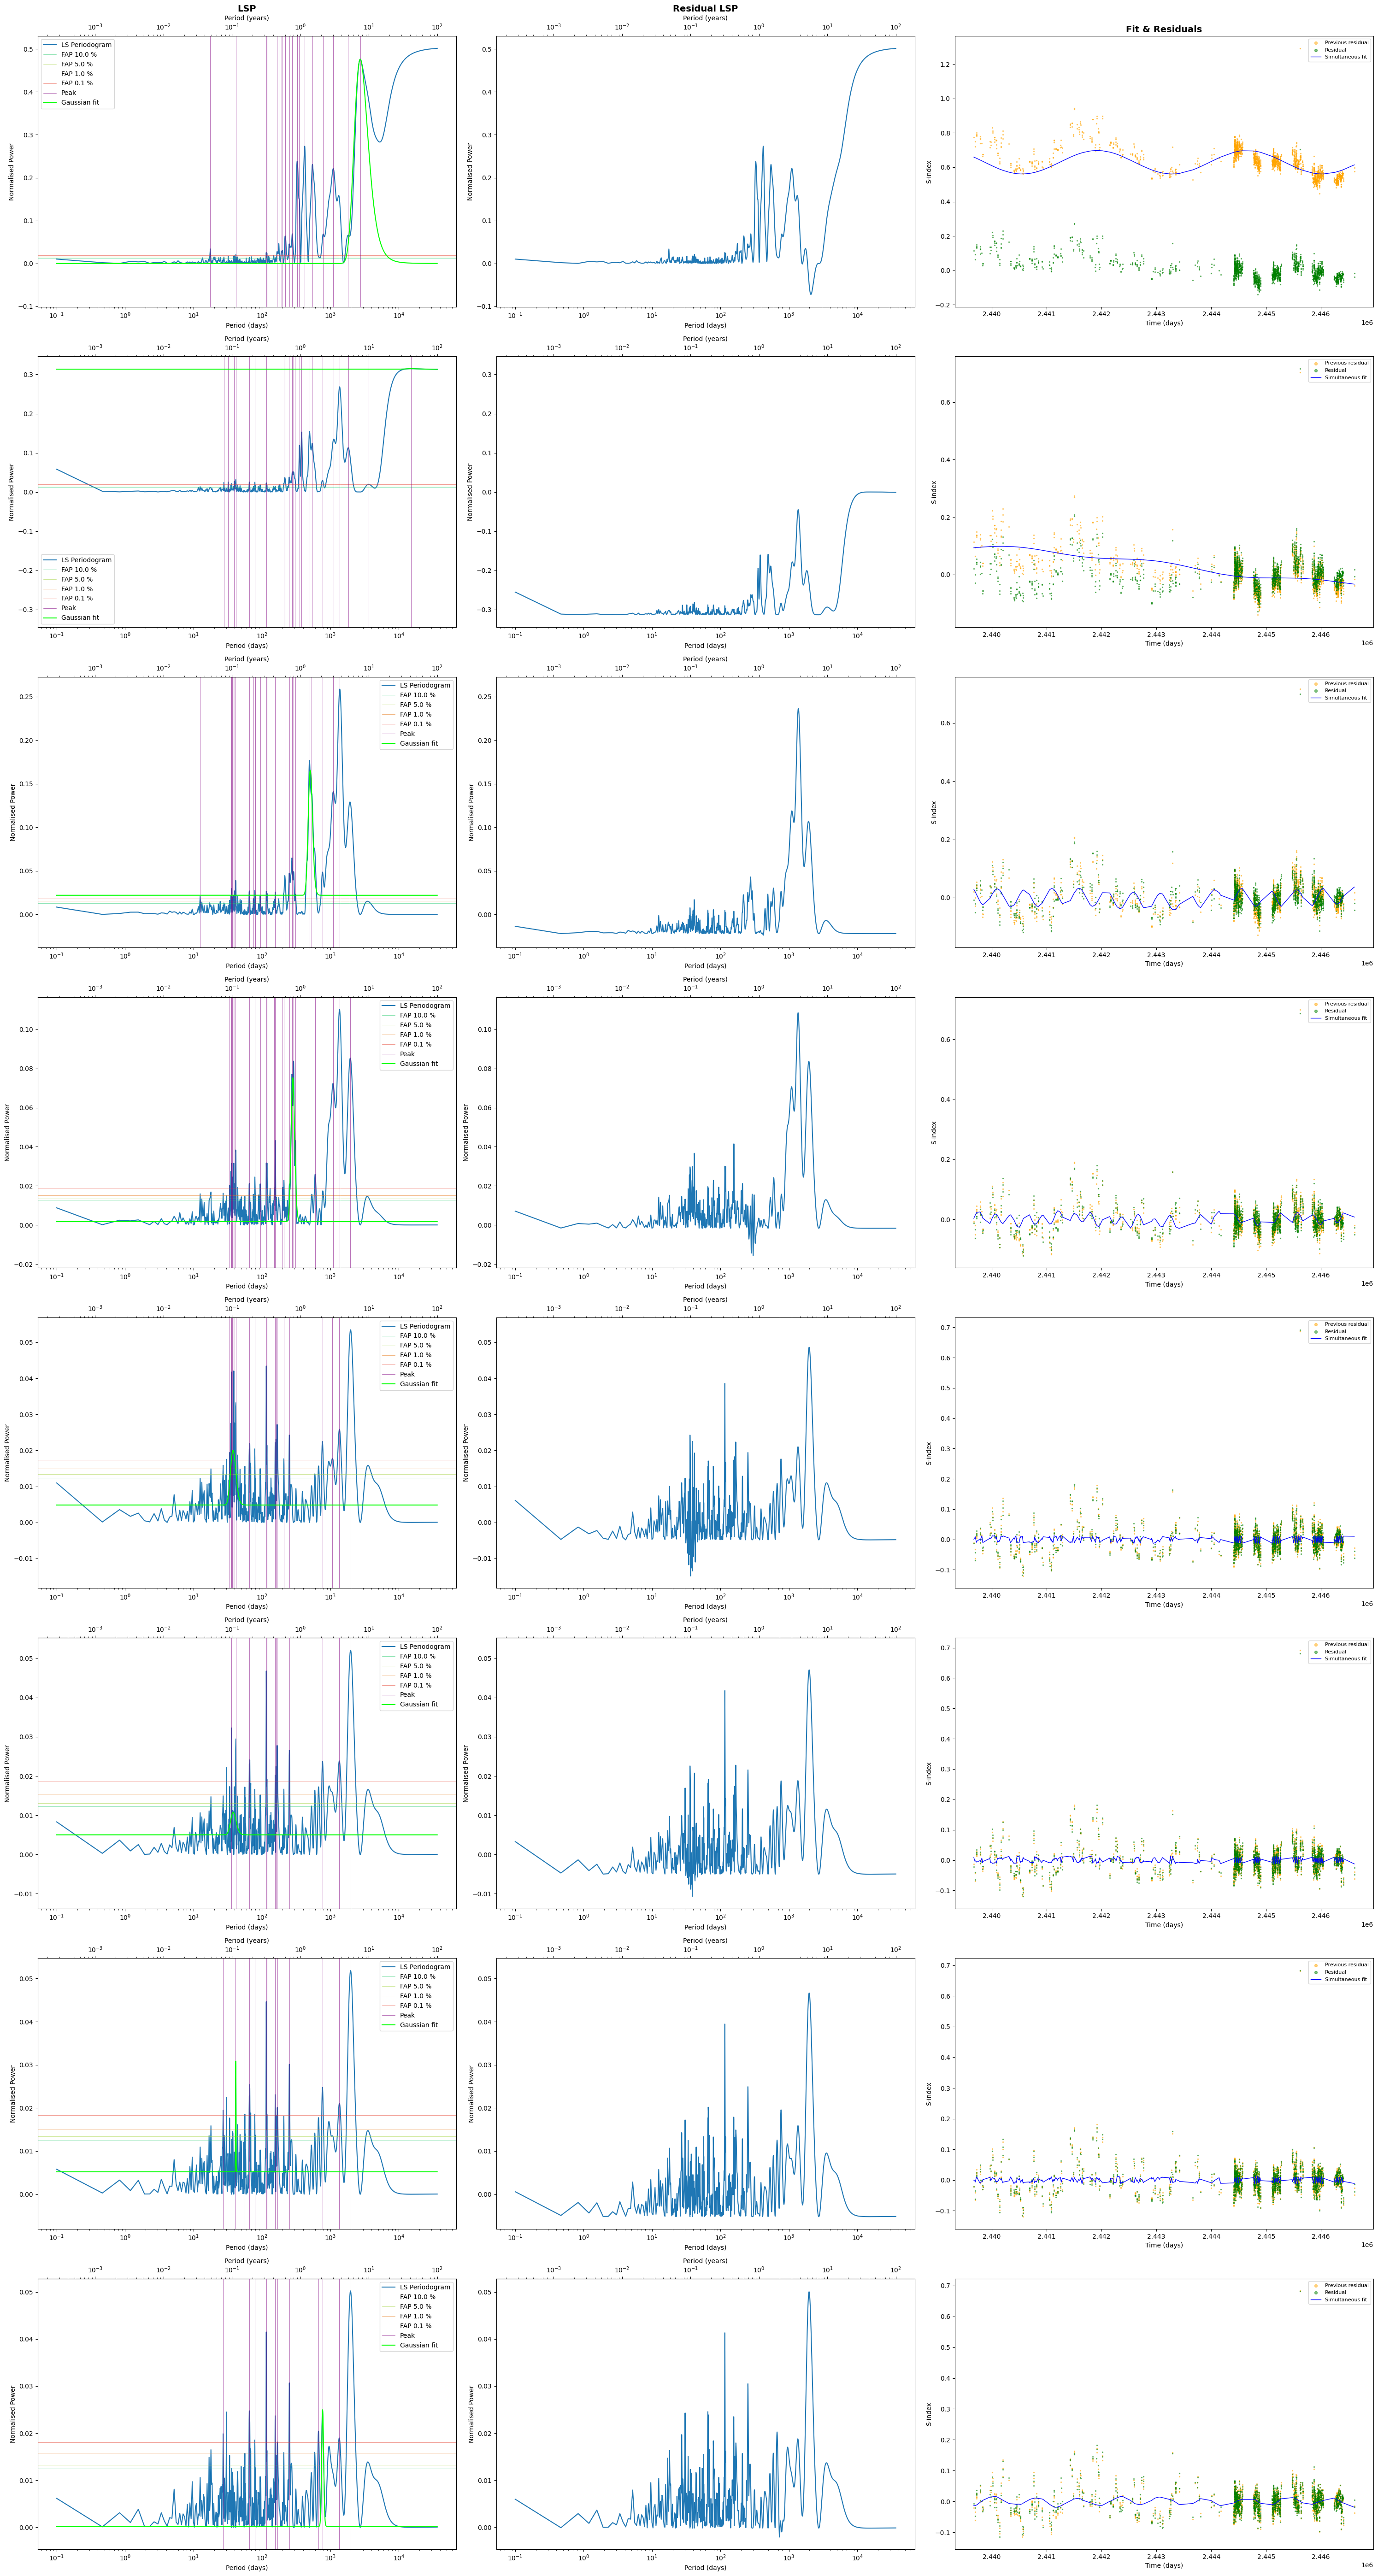

Accepted periods and their heights
+----------+-------+--------+---------------+
|   Days   | Years | Height |      SNR      |
+----------+-------+--------+---------------+
| 2734.70  |  7.49 | 0.4761 |    28976.68   |
| 15173.63 | 41.57 | 0.3145 | 2303608059.61 |
|  495.77  |  1.36 | 0.1769 |     13.65     |
|  289.91  |  0.79 | 0.0838 |     10.60     |
|  38.79   |  0.11 | 0.0421 |      7.06     |
|  35.87   |  0.10 | 0.0323 |      5.78     |
|  41.35   |  0.11 | 0.0297 |      5.76     |
|  767.70  |  2.10 | 0.0249 |     23.39     |
+----------+-------+--------+---------------+


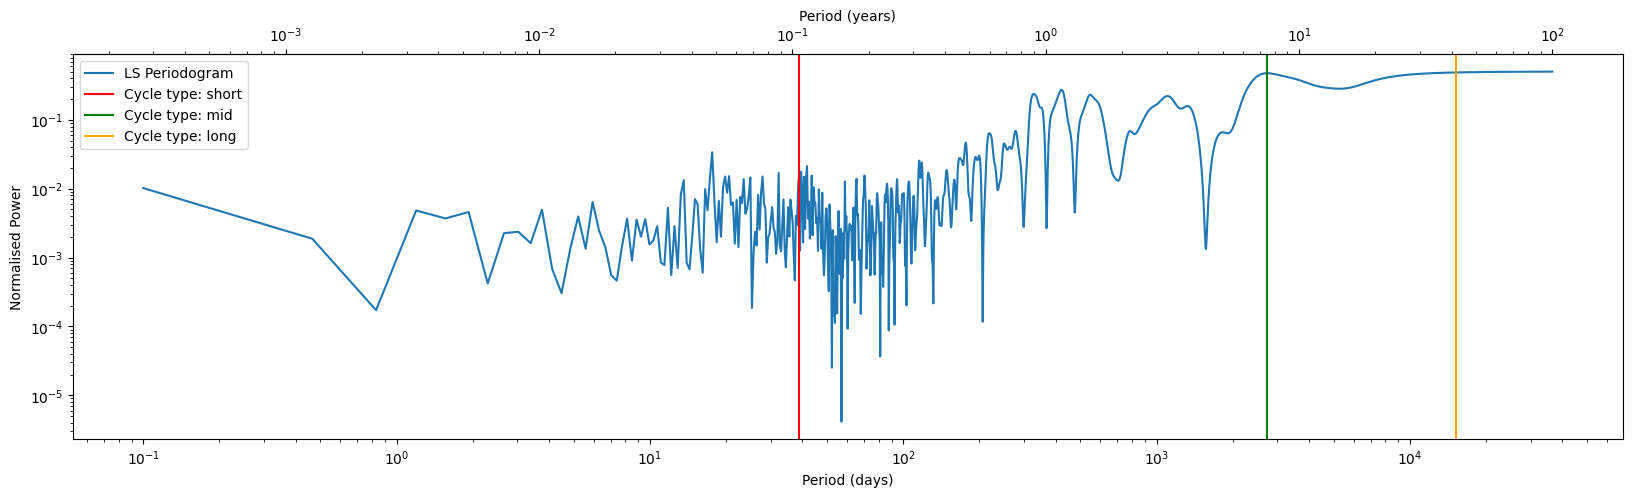

Classified Signals
+------------+------------+-------------+
| Cycle Type | Prior Days | Prior Years |
+------------+------------+-------------+
|   Short    |   38.79    |     0.11    |
|    Mid     |  2734.70   |     7.49    |
|    Long    |  15173.63  |    41.57    |
+------------+------------+-------------+
+------------+------------+-------------+----------------------+----------------+--------+
| Cycle Type | Prior Days | Prior Years |     Bounds Days      |  Bounds Years  | Source |
+------------+------------+-------------+----------------------+----------------+--------+
|   Short    |   38.79    |     0.11    |    (34.91, 42.67)    |  (0.10, 0.12)  | found  |
|    Mid     |  2734.70   |     7.49    |  (2461.23, 3008.17)  |  (6.74, 8.24)  | found  |
|    Long    |  15173.63  |    41.57    | (13656.26, 16690.99) | (37.41, 45.73) | found  |
+------------+------------+-------------+----------------------+----------------+--------+


In [36]:
#-----LSP------

classified_signal_data = find_classify_signals(dirty_train_df,
                                               plot_fitpeaks=plot, verbose_fitpeaks=verbose,
                                               plot_genpriors=plot, verbose_genpriors=verbose)

rho_priors, rho_prior_bounds, rho_sources = get_priors(classified_signal_data,
                                                       star_type=star_type,
                                                       direct_bound_tol=direct_bound_tol,
                                                       sm2016_bound_tol=sm2016_bound_tol,
                                                       mean_bound_tol=mean_bound_tol,
                                                       verbose=verbose)

1m | CRPS=0.0422 | NLPD=-1.0531
+--------+------+------------+-------------+
| sigma  |  Q   | rho (days) | rho (years) |
+--------+------+------------+-------------+
| 0.3691 | 5.00 |  2461.23   |     6.74    |
+--------+------+------------+-------------+


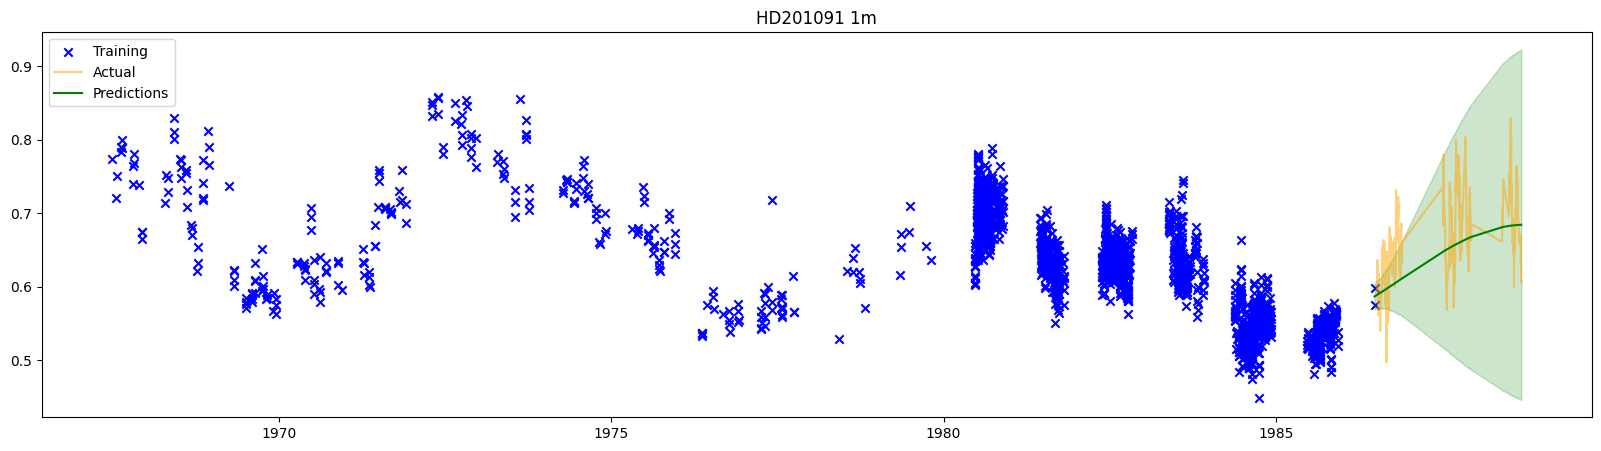

2sm | CRPS=0.0320 | NLPD=-1.3635
+--------+------+------------+-------------+
| sigma  |  Q   | rho (days) | rho (years) |
+--------+------+------------+-------------+
| 0.0497 | 5.00 |   34.91    |     0.10    |
| 0.1364 | 5.00 |  2461.23   |     6.74    |
+--------+------+------------+-------------+


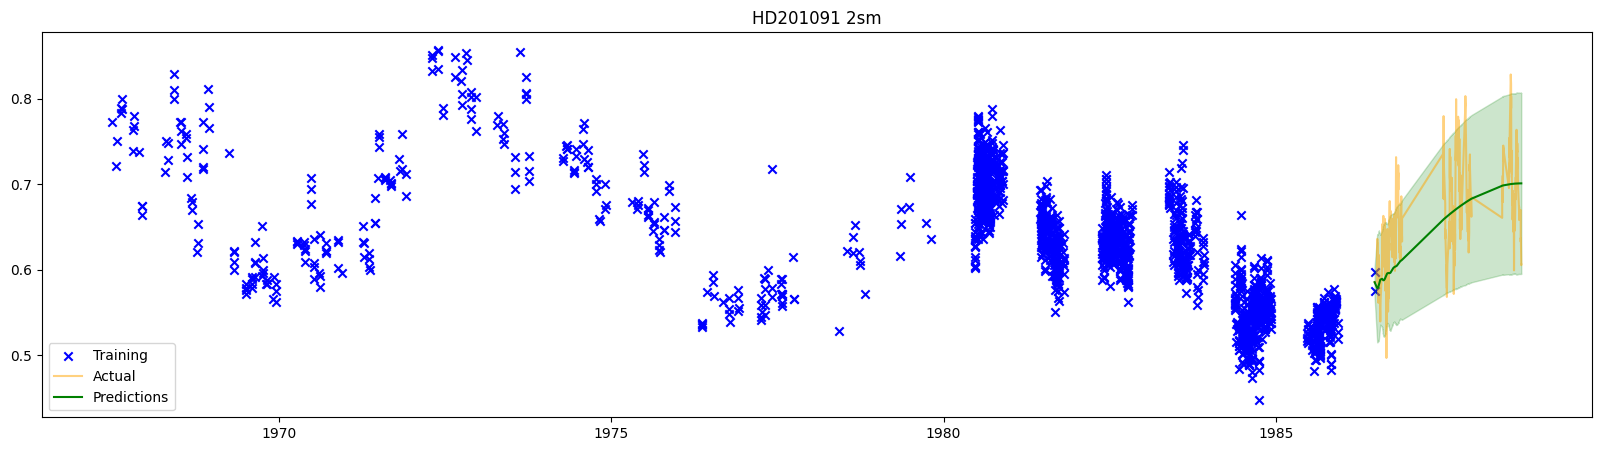

2ml | CRPS=0.0422 | NLPD=-1.0526
+--------+------+------------+-------------+
| sigma  |  Q   | rho (days) | rho (years) |
+--------+------+------------+-------------+
| 0.3691 | 5.00 |  2461.23   |     6.74    |
| 0.0065 | 7.76 |  16207.27  |    44.40    |
+--------+------+------------+-------------+


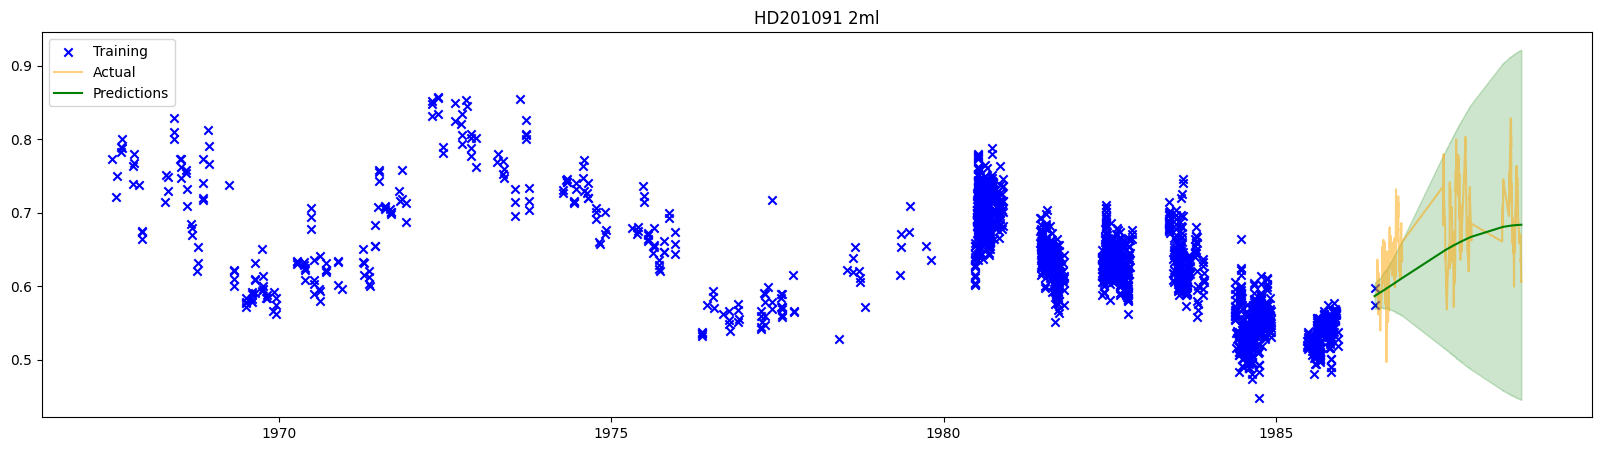

3sml | CRPS=0.0423 | NLPD=-1.2046
+--------+--------+------------+-------------+
| sigma  |   Q    | rho (days) | rho (years) |
+--------+--------+------------+-------------+
| 0.0505 |  5.00  |   34.91    |     0.10    |
| 0.1083 |  5.00  |  2461.23   |     6.74    |
| 0.0411 | 100.00 |  14606.26  |    40.02    |
+--------+--------+------------+-------------+


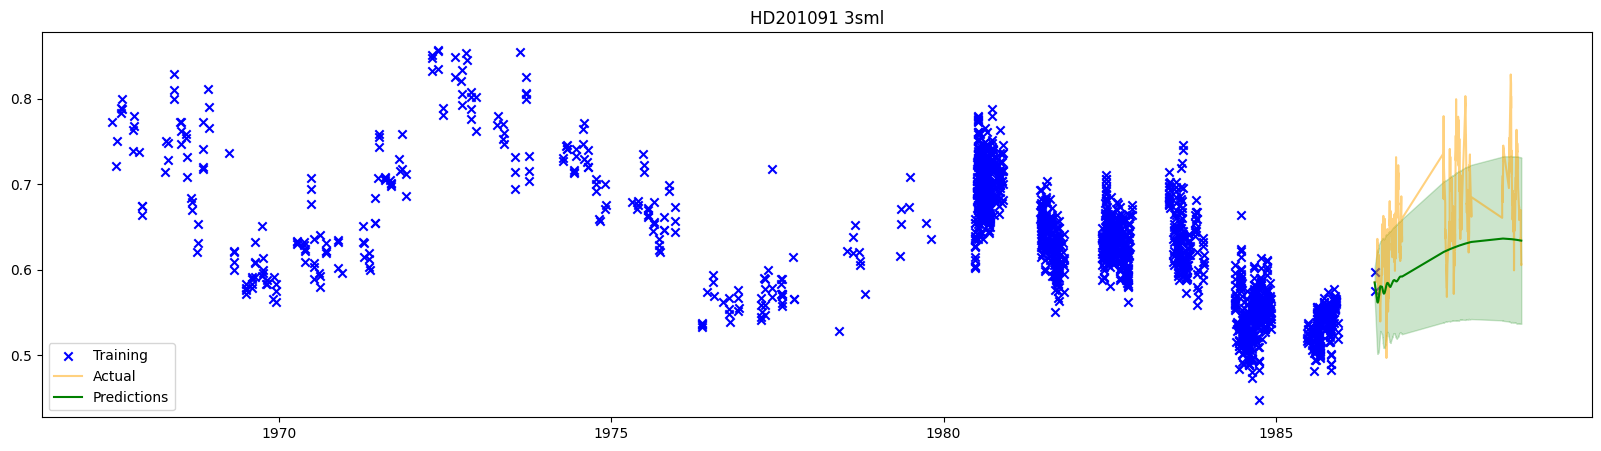

const | CRPS=0.0595 | NLPD=-0.8293
+--------+------+------------+-------------+
| sigma  |  Q   | rho (days) | rho (years) |
+--------+------+------------+-------------+
| 0.3691 | 0.02 |  2461.23   |     6.74    |
+--------+------+------------+-------------+


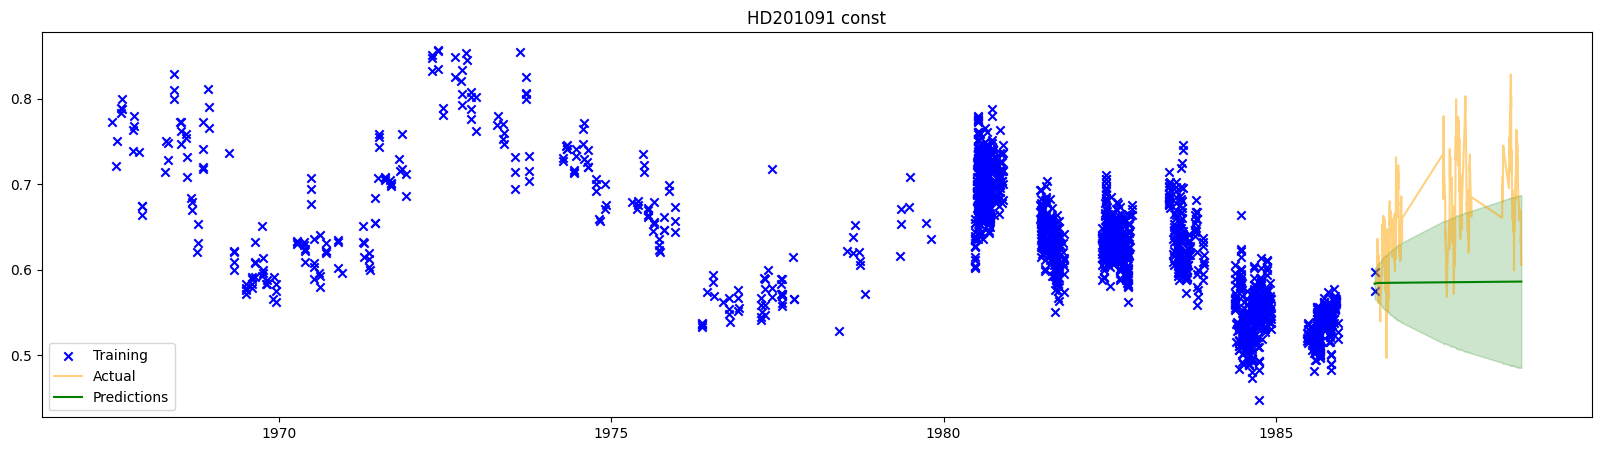

In [37]:
#-------Model comparison and selection--------

# Some required statistics
train_yerr = train_df['sind'] * error_percent / 100
train_mean = train_df['sind'].mean()
train_std  = train_df['sind'].std()

# Define the mosels to search
prior_combos = {
    "1m":    {'k': 1, 'q_priors': None,         'cycle_keys': ['mid']},
    "2sm":   {'k': 2, 'q_priors': None,         'cycle_keys': ['short', 'mid']},
    "2ml":   {'k': 2, 'q_priors': None,         'cycle_keys': ['mid',   'long']},
    "3sml":  {'k': 3, 'q_priors': None,         'cycle_keys': ['short', 'mid', 'long']},
    "const": {'k': 1, 'q_priors': "overdamped", 'cycle_keys': ['mid']},
}

if require_mid:
    prior_combos = {key: val for key, val in prior_combos.items() if 'mid' in val['cycle_keys']}

# Loop through combos
combo_results = {}

for combo_name, combo_info in prior_combos.items():
    # Extract combo information
    k = combo_info['k']
    q_prior_type = combo_info['q_priors']
    cycle_keys = combo_info['cycle_keys']

    # Repeatability
    np.random.seed(SEED)

    # Initial guesses
    q_0s = [np.random.uniform(0, 0.5) for _ in range(k)] if q_prior_type == 'overdamped' else \
               [np.random.uniform(0.5, 1) for _ in range(k)]
    sigma_0s = [train_std / k for _ in range(k)]
    rho_0s   = [rho_priors[ck] for ck in cycle_keys]

    initial_guess = np.concatenate([np.log(sigma_0s), np.log(rho_0s), np.log(q_0s)])

    # Defining bounds
    q_bounds  = [(-np.inf, np.log(0.5)) for _ in range(k)] if q_prior_type == 'overdamped' else \
                   [(np.log(q_bounds_in[0]), np.log(q_bounds_in[1])) for _ in range(k)]
    sigma_bounds = [(np.log(1e-4), np.log(train_std * sigma_upper_mult)) for _ in range(k)]
    rho_bounds   = np.log([rho_prior_bounds[ck] for ck in cycle_keys])
    bounds       = np.concatenate([sigma_bounds, rho_bounds, q_bounds])

    # Define initial kernel based on the combo info
    kernel = terms.SHOTerm(sigma=sigma_0s[0], rho=rho_0s[0], Q=q_0s[0])
    for k_idx in range(1, k):
        kernel += terms.SHOTerm(sigma=sigma_0s[k_idx], rho=rho_0s[k_idx], Q=q_0s[k_idx])

    # Define the gp
    gp = celerite2.GaussianProcess(kernel, mean=train_mean)
    gp.compute(train_df['day'], yerr=train_yerr)

    # Optimise the gp for that combo
    gp_results = minimize(NLL, initial_guess,
                          args=(gp, k, train_df['sind'].to_numpy()),
                          method='L-BFGS-B', bounds=bounds)
    
    # Set the gp to the best params
    gp = set_params(gp_results.x, k, gp)
    gp.recompute()
    best_params = np.exp(gp_results.x)

    # Calculate the performance on the validation set
    mu, cov = gp.predict(train_df['sind'], t=valid_df['day'], return_var=True)
    y_valid = valid_df['sind'].to_numpy()
    valid_yerr = valid_df['sind'] * error_percent / 100
    total_std  = np.sqrt(cov + valid_yerr**2)

    # Calculate the NLPD based on those performance statts
    total_var = cov + valid_yerr**2
    nlpd_per_point = 0.5 * np.log(2 * np.pi * total_var) + (y_valid - mu)**2 / (2 * total_var)
    mean_nlpd = nlpd_per_point.mean()

    # Calcilate the CRPS based on those performance stats
    z = (y_valid - mu) / total_std
    crps = total_std * (z * (2 * norm.cdf(z) - 1) + 2 * norm.pdf(z) - 1/np.sqrt(np.pi))
    mean_crps = crps.mean()

    # Save the results
    combo_results[combo_name] = {
        "NLPD": mean_nlpd, "CRPS": mean_crps,
        "gp": gp, "params": best_params,
        "initial_guess": initial_guess, "bounds": bounds,
    }

    # Plot and print
    if loop_verbose:
        table = PrettyTable(["sigma", "Q", "rho (days)", "rho (years)"])
        best_sigmas, best_rhos, best_qs = best_params[:k], best_params[k:2*k], best_params[2*k:]
        for k_idx in range(k):
            table.add_row([f"{best_sigmas[k_idx]:.4f}", f"{best_qs[k_idx]:.2f}",
                           f"{best_rhos[k_idx]:.2f}", f"{best_rhos[k_idx]/365:.2f}"])
        print(f"{combo_name} | CRPS={mean_crps:.4f} | NLPD={mean_nlpd:.4f}")
        print(table)

    if loop_plot:
        loop_fig, loop_ax = plt.subplots(figsize=(20, 5))
        loop_ax.scatter(train_df['year'], train_df['sind'], color='blue', label='Training', marker='x')
        loop_ax.plot(valid_df['year'], valid_df['sind'], color='orange', label='Actual', alpha=0.5)
        loop_ax.plot(valid_df['year'], mu, color='green', label='Predictions')
        loop_ax.fill_between(valid_df['year'], mu - total_std, mu + total_std, color='green', alpha=0.2)
        loop_ax.set_title(f"{star_name} {combo_name}")
        loop_ax.legend()
        plt.show()


In [38]:
#------Choosing the model--------
lowest_valid_metric = np.inf
best_combo_name = None
for combo_name, combo_result in combo_results.items():
    if combo_result[valid_metric] < lowest_valid_metric:
        lowest_valid_metric = combo_result[valid_metric]
        best_combo_name = combo_name
        best_gp = combo_result['gp']
        best_params = combo_result['params']
        best_initial_guess = combo_result['initial_guess']
        best_bounds = combo_result['bounds']

if verbose:
    print(f"Selected model: {best_combo_name} ({valid_metric}={lowest_valid_metric:.4f})")

Selected model: 2sm (CRPS=0.0320)


- Now perform the predictions on the test set.
- First, retrain that model combo on the training + validation sets.

In [39]:
#----Retrain on valid + train sets--------

# Combine the datasets
retrain_df = df = pd.concat([train_df, valid_df])

# Getting the winning model params
combo_info = prior_combos[best_combo_name]
k = combo_info['k']
q_prior_type = combo_info['q_priors']
cycle_keys = combo_info['cycle_keys']

# Redefining the statistics
retrain_yerr = retrain_df['sind'] * error_percent / 100
retrain_mean = retrain_df['sind'].mean()

# Initial guesses as the best params from first optimisation
initial_guess = np.log(best_params)  # back to log space for the optimiser

# Build the kernel
params = np.exp(initial_guess)
kernel = terms.SHOTerm(sigma=params[0], rho=params[k], Q=params[2*k])
for k_idx in range(1, k):
    kernel += terms.SHOTerm(sigma=params[k_idx], rho=params[k + k_idx], Q=params[2*k + k_idx])

# Train that
gp_retrain = celerite2.GaussianProcess(kernel, mean=retrain_mean)
gp_retrain.compute(retrain_df['day'], yerr=retrain_yerr)

retrain_results = minimize(NLL, initial_guess,
                             args=(gp_retrain, k, retrain_df['sind'].to_numpy()),
                             method='L-BFGS-B', bounds=best_bounds)

gp_retrain = set_params(retrain_results.x, k, gp_retrain)
gp_retrain.recompute()
retrain_params = np.exp(retrain_results.x)


  0%|          | 0/5000 [00:00<?, ?it/s]c:\Users\Joey\Desktop\Cambridge\Work\Thesis\VenvThesis\lib\site-packages\emcee\moves\red_blue.py:99: RuntimeWarning: invalid value encountered in scalar subtract
  lnpdiff = f + nlp - state.log_prob[j]
100%|██████████| 5000/5000 [01:36<00:00, 52.05it/s]


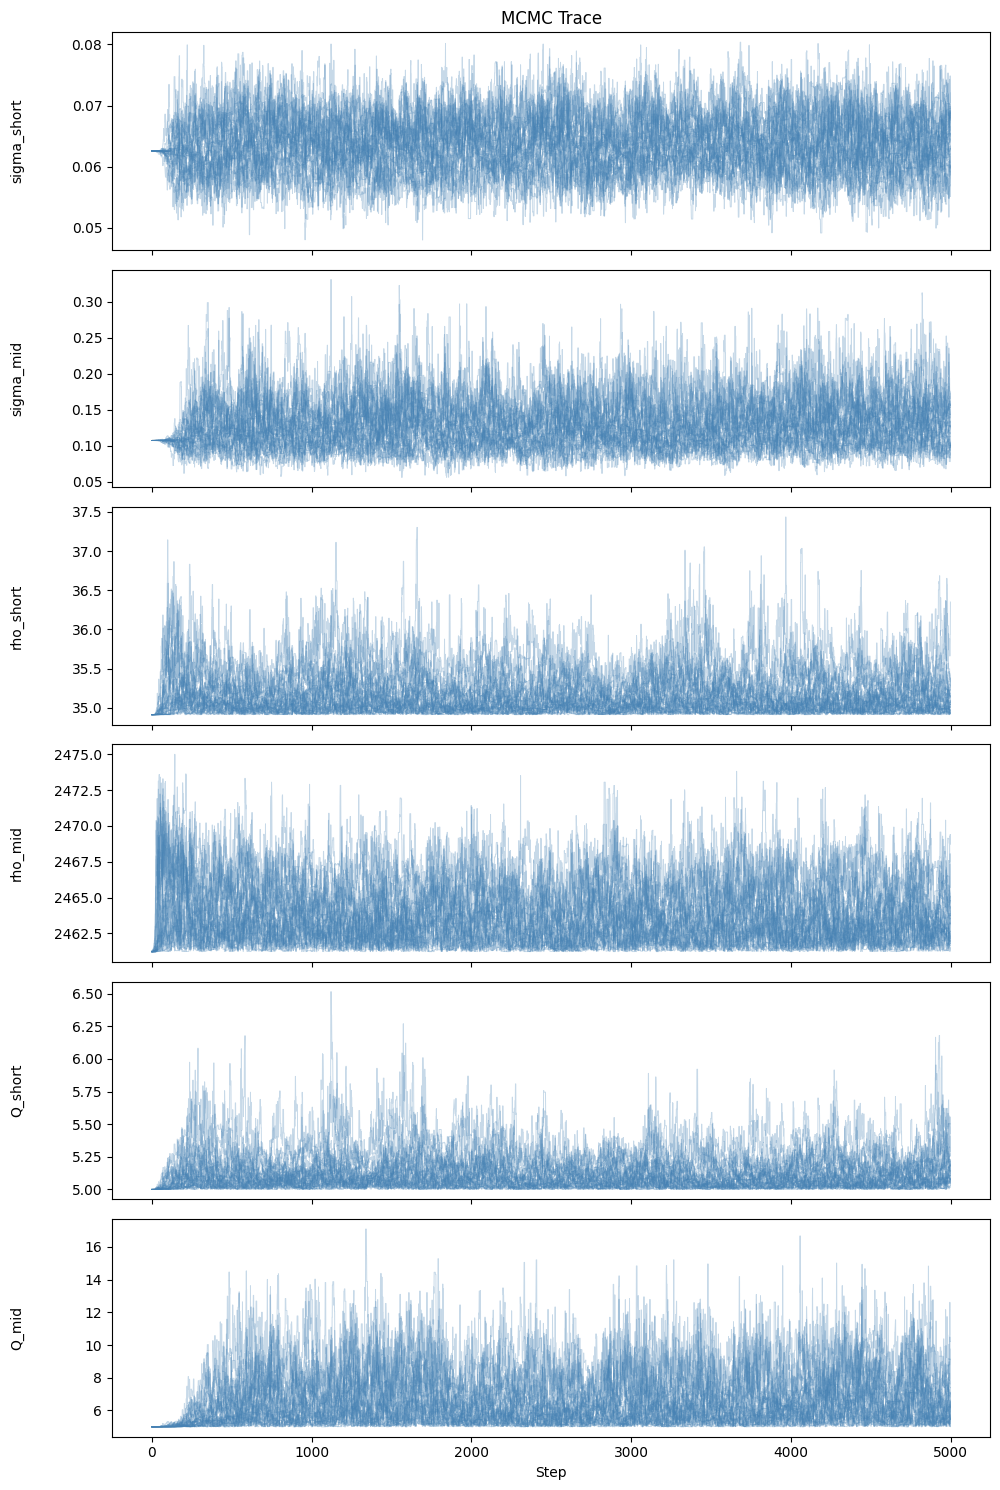

In [40]:
#------MCMC on the retrained--------
np.random.seed(SEED)

y = retrain_df['sind'].to_numpy()

walker_start_coords = np.log(retrain_params) + 1e-5 * np.random.randn(n_walkers, len(retrain_params))

sampler = emcee.EnsembleSampler(n_walkers, len(retrain_params), lnPost,
                args=(gp_retrain, k, y, retrain_results.x, best_bounds)) # We have used the retrained results as the initial conds
sampler.run_mcmc(walker_start_coords, nsteps=total_sample_count, progress=True)

if sampler_plot:
    cycle_keys  = prior_combos[best_combo_name]['cycle_keys']
    param_names = ([f'sigma_{ck}' for ck in cycle_keys] +
                   [f'rho_{ck}'   for ck in cycle_keys] +
                   [f'Q_{ck}'     for ck in cycle_keys])
    plot_trace(sampler, param_names)

ln_chains = sampler.get_chain(discard=1000)
ln_samples = ln_chains.reshape(-1, ln_chains.shape[-1])

np.random.seed(SEED)
idx = np.random.choice(len(ln_samples), size=subsample, replace=False)
ln_samples = ln_samples[idx]

In [98]:
from tqdm import tqdm

In [99]:
#-----------Predict the retrained gp forward-----------

#### this should be in the function signature
overlap_years = 5
pred_forward_years = 6
result_plot_cadence = 50
####

# Define the prediction grid
day_ref = retrain_df['day'].iloc[0]
year_ref = retrain_df['year'].iloc[0]

t_start = max(retrain_df['day'].iloc[-1] - 365 * overlap_years, day_ref) # This is a measure to prevent the ringing
# # t_start = day_ref
t_end = max(retrain_df['day'].iloc[-1] + 365 * pred_forward_years, test_df['day'].iloc[-1]) # Always predict to the end anyways
# sampled_days = np.arange(t_start, t_end, result_plot_cadence)


t_retrain_end = retrain_df['day'].iloc[-1]
t_ring_end    = t_retrain_end + 365  # end of ringing zone

low_res  = 100  # during retraining overlap
mid_res  = 50   # first year of preds (ringing zone)
high_res = 1   # thereafter

sampled_days = np.concatenate([
    np.arange(t_start,       t_retrain_end, low_res),
    np.arange(t_retrain_end, t_ring_end,    mid_res),
    np.arange(t_ring_end,    t_end,         high_res),
])

# Define some axes things
sampled_years = year_ref + (sampled_days - day_ref) / 365

# Posterior predictions
mus, variances = [], []
for i, ln_sample in enumerate(ln_samples):
    set_params(ln_sample, k, gp_retrain)
    gp_retrain.recompute(quiet=True)
    mu, var = gp_retrain.predict(retrain_df['sind'], t=sampled_days, return_var=True)
    mus.append(mu)
    variances.append(var)
    if (i + 1) % 100 == 0:
        print(f"{i + 1}/{len(ln_samples)}")


# mus, variances = [], []
# for ln_sample in ln_samples:
#     set_params(ln_sample, k, gp_retrain)
#     gp_retrain.recompute(quiet=True)
#     mu, var = gp_retrain.predict(retrain_df['sind'], t=sampled_days, return_var=True)
#     mus.append(mu)
#     variances.append(var)


started


In [100]:
#---------Use posterior samples to return useful info---------

# Turn posterior sampels into np arrays
mus = np.array(mus) # central values of every posterior sample vs time
variances = np.array(variances) # variance vs time

# Get the posterior mean
mean_pred = mus.mean(axis=0) 

# We want to ignore the lookback predictions we used to clean the ringing
t0 = retrain_df['day'].iloc[-1]
pred_mask = sampled_days > t0
fut_preds = mus[:,pred_mask]
fut_t = sampled_days[pred_mask]
fut_mean = mus[:, pred_mask].mean(axis=0) # for plotitng unc
fut_vars = variances[:, pred_mask]
fut_years = sampled_years[pred_mask]

# Check if constant
def check_constant(predictions, MAD, tol = 2, percentile = 84):
    '''
    Helper function to check if the variations in a forecast is not significant compared to the noise.
    Noise is defined by the MAD of the training set.
    t0 is the actual prediction start point

    Returns true if constant within 1std.
    '''
    amps = predictions.max(axis=1) - predictions.min(axis=1)

    return np.percentile(amps, percentile) / MAD < tol

def best_in_x(predictions, t, lookahead_years, t_start=None):
    '''
    Takes a look at the predictions starting at the start of prediction time t0.
    Finds the lowest predicted SInd in the next 'years' years.
    If years > prediction range, warn and then give the best in the prediction range.
    This is regardless of which the first peak is.

    Inputs
        t are the days at which the predictions are rpedicted
        Years is the lookahead

    Return time relative to start of predictions of the best time.
    '''  
    t_start = t_start if t_start is not None else t[0]

    lookahead_days = lookahead_years * 365

    t_end = t_start + lookahead_days
    if t_end > t[-1]:
        t_end = t[-1]
        # Warn
        print("t_end is after the end of the predictions. Extend prediction window!")

    # Get the predictions that are before t_end
    mask = t < t_end
    window_predictions = predictions[:,mask]
    window_t = t[mask]

    # Get the minima from each posterior-sampled prediction
    min_t = window_t[np.argmin(window_predictions, axis=1)]
    median_min_t = np.median(min_t)
    lb_min_t, hb_min_t = np.percentile(min_t, [16,84])

    return median_min_t, (lb_min_t, hb_min_t)

# Adding the gaussian smoothing                                                                                                    
def gaussian_smooth(t, y, sigma, n_eval=1000):                                                                                             
    t_eval = np.linspace(t.min(), t.max(), n_eval)                                                                                        
    w = np.exp(-0.5 * ((t[:, None] - t_eval[None, :]) / sigma) ** 2)                                                                       
    return t_eval, (w * y[:, None]).sum(axis=0) / w.sum(axis=0)          

def window_truths(data_df, year_ref, day_ref, t0_year, lookahead_years,
                    span_multipliers=None):
    
    if span_multipliers is None:
        span_multipliers = np.linspace(0.02, 0.08, 30)

    span = data_df['day'].max() - data_df['day'].min()

    best_times = []
    for mult in span_multipliers:
        t_day_s, y_s = gaussian_smooth(data_df['day'].values, data_df['sind'].values, sigma=span * mult)
        t_year_s     = year_ref + (t_day_s - day_ref) / 365

        fut_mask = t_year_s > t0_year
        fut_t_s  = t_year_s[fut_mask]
        fut_y_s  = y_s[fut_mask]

        window_mask = fut_t_s <= t0_year + lookahead_years
        if not window_mask.any():
            continue
        best_times.append(fut_t_s[window_mask][np.argmin(fut_y_s[window_mask])])

    best_times = np.array(best_times)
    return np.median(best_times), tuple(np.percentile(best_times, [16, 84]))

# Use the funcs
is_const = check_constant(fut_preds, MAD)

best_in_1 = best_in_x(predictions = fut_preds, t = fut_t, lookahead_years = 1, t_start = t0)
best_in_2 = best_in_x(predictions = fut_preds, t = fut_t, lookahead_years = 2, t_start = t0)
best_in_3 = best_in_x(predictions = fut_preds, t = fut_t, lookahead_years = 3, t_start = t0)
best_in_4 = best_in_x(predictions = fut_preds, t = fut_t, lookahead_years = 4, t_start = t0)
best_in_5 = best_in_x(predictions = fut_preds, t = fut_t, lookahead_years = 5, t_start = t0)


C:\Users\Joey\AppData\Local\Temp\ipykernel_6348\2333477025.py:92: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax2.legend()


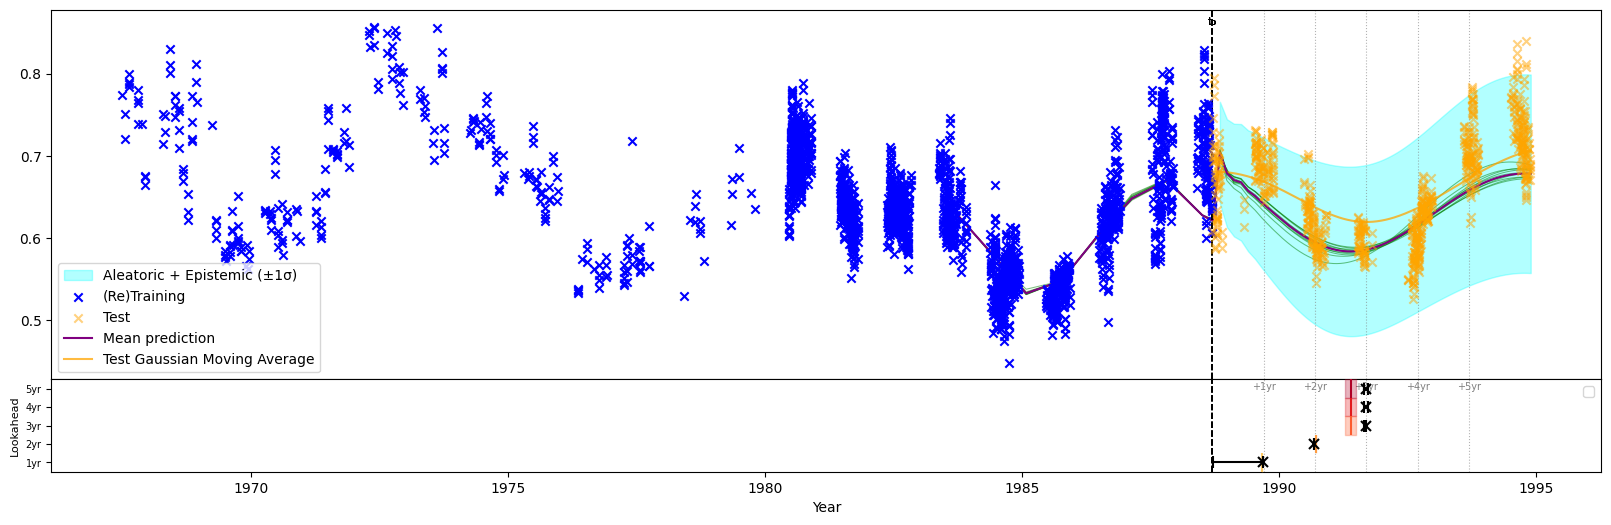

In [101]:
def to_year(day):
    return year_ref + (day - day_ref) / 365

#---------Plot----------

# Calculate errors
aleatoric = fut_vars.mean(axis=0) # Random noise
epistemic = fut_preds.var(axis=0) # Uncertainty in the model params 
total_std = np.sqrt(aleatoric + epistemic)

###
# Uncertainty between model combos to be examined in the future
###

fig, (ax, ax2) = plt.subplots(2, 1, figsize=(20, 6), sharex=True,
                                gridspec_kw={'height_ratios': [4, 1]})
plt.subplots_adjust(hspace=0)

# MAIN FORECAST PANEL 

# Plot some samples
for idx, mu in enumerate(mus):
    if idx % plot_every == 0:
        ax.plot(sampled_years, mu, color='green', alpha=0.5, lw=0.75)

# Plot the uncertainties
ax.fill_between(fut_years,
                fut_mean - total_std,
                fut_mean + total_std,
                color='cyan', alpha=0.3, label='Aleatoric + Epistemic (±1σ)', zorder=1)

# Plot the datasets
ax.scatter(retrain_df['year'], retrain_df['sind'], color='blue',   label='(Re)Training', marker='x', zorder=4)
ax.scatter(test_df['year'], test_df['sind'], color='orange', label='Test',   marker='x', alpha=0.5, zorder=4)

# Plot the posterior mean
ax.plot(sampled_years, mean_pred, color='purple', label='Mean prediction', zorder=3)

t0_year = retrain_df['year'].iloc[-1]  # When it actually starts predicting

# Gaussian smooth over full data for ground truth overlay
span = data_df['day'].max() - data_df['day'].min()
t_day_smooth, y_smooth = gaussian_smooth(data_df['day'].values, data_df['sind'].values, sigma=span * 0.04)
t_year_smooth = year_ref + (t_day_smooth - day_ref) / 365
fut_mask = t_year_smooth > t0_year
fut_year_smooth = t_year_smooth[fut_mask] 
fut_y_smooth = y_smooth[fut_mask]
ax.plot(fut_year_smooth, fut_y_smooth, label="Test Gaussian Moving Average", color="orange", alpha=0.75)


# LOOKAHEAD PANEL

window_truth_1 = window_truths(data_df, year_ref, day_ref, t0_year, lookahead_years=1)
window_truth_2 = window_truths(data_df, year_ref, day_ref, t0_year, lookahead_years=2)
window_truth_3 = window_truths(data_df, year_ref, day_ref, t0_year, lookahead_years=3)
window_truth_4 = window_truths(data_df, year_ref, day_ref, t0_year, lookahead_years=4)
window_truth_5 = window_truths(data_df, year_ref, day_ref, t0_year, lookahead_years=5)

# Year boundary lines on both panels
for yr in range(1, 6):
    for a in (ax, ax2):
        a.axvline(t0_year + yr, color='gray', linestyle=':', lw=0.8, alpha=0.6, zorder=2)
        a.axvline(t0_year, color='black', linestyle='--', lw=1.2, alpha=0.8, zorder=3)
        ax.text(t0_year, 0.98, 't₀', transform=ax.get_xaxis_transform(), ha='center', va='top', fontsize=8)
    ax2.text(t0_year + yr, 4.85, f'+{yr}yr', ha='center', va='top', fontsize=7, color='gray')

# Best-in-x years bands
best_results = [best_in_1, best_in_2, best_in_3, best_in_4, best_in_5]
bix_colors = plt.cm.YlOrRd(np.linspace(0.3, 0.9, 5))

for i, (med, (lb, hb)) in enumerate(best_results):
    med_yr, lb_yr, hb_yr = to_year(med), to_year(lb), to_year(hb)
    ax2.fill_betweenx([i, i + 1], lb_yr, hb_yr, color=bix_colors[i], alpha=0.3, zorder=3)
    ax2.vlines(med_yr, i, i + 1, color=bix_colors[i], lw=1.5, zorder=4)

# Get and plot the window truths
window_truth_results = [window_truth_1, window_truth_2, window_truth_3, window_truth_4, window_truth_5]
for i, (med, (lb, hb)) in enumerate(window_truth_results):
    ax2.errorbar(med, i + 0.5,
                xerr=[[med - lb], [hb - med]],
                fmt='x', color='black', capsize=4, capthick=1.5,
                elinewidth=1.5, markersize=7, markeredgewidth=1.5,
                zorder=5)

ax2.set_ylim(0, 5)
ax2.set_yticks([0.5, 1.5, 2.5, 3.5, 4.5])
ax2.set_yticklabels(['1yr', '2yr', '3yr', '4yr', '5yr'], fontsize=7)
ax2.set_ylabel("Lookahead", fontsize=8)
ax2.set_xlabel("Year")

ax.legend()
ax2.legend()
plt.show()


In [102]:
from prettytable import PrettyTable

t0_year    = to_year(t0)
t_end_year = to_year(fut_t[-1])

table = PrettyTable(["Label", "Search from", "Search to", "Median", "68% CI"])
table.align = "r"
table.align["Label"] = "l"

def add_row(label, search_from, search_to, med, ci):
    if np.isnan(med):
        table.add_row([label, f"{search_from:.2f}", f"{search_to:.2f}", "not found", "—"])
    else:
        table.add_row([label, f"{search_from:.2f}", f"{search_to:.2f}",
                        f"{to_year(med):.2f}",
                        f"{to_year(ci[0]):.2f} – {to_year(ci[1]):.2f}"])

for i, (med, (lb, hb)) in enumerate(best_results):
    add_row(f"Best in {i+1}yr", t0_year, t0_year + (i + 1), med, (lb, hb))

print(table)

+-------------+-------------+-----------+---------+-------------------+
| Label       | Search from | Search to |  Median |            68% CI |
+-------------+-------------+-----------+---------+-------------------+
| Best in 1yr |     1988.71 |   1989.71 | 1989.67 | 1989.67 – 1989.67 |
| Best in 2yr |     1988.71 |   1990.71 | 1990.70 | 1990.70 – 1990.70 |
| Best in 3yr |     1988.71 |   1991.71 | 1991.40 | 1991.28 – 1991.50 |
| Best in 4yr |     1988.71 |   1992.71 | 1991.40 | 1991.28 – 1991.50 |
| Best in 5yr |     1988.71 |   1993.71 | 1991.40 | 1991.28 – 1991.50 |
+-------------+-------------+-----------+---------+-------------------+


In [55]:
# if is_const:
#     print("Forecast is approximately constant — no meaningful cycle detected.")
# else:
def fmt_result(label, med, ci):
    if np.isnan(med):
        print(f"{label}: not found in forecast window")
    else:
        print(f"{label}: {to_year(med):.2f} (68% CI: {to_year(ci[0]):.2f} – {to_year(ci[1]):.2f})")

for i, (med, (lb, hb)) in enumerate(best_results):
    fmt_result(f"Best in {i+1}yr ", med, (lb, hb))

Best in 1yr : 1988.72 (68% CI: 1988.72 – 1988.72)
Best in 2yr : 1990.70 (68% CI: 1990.70 – 1990.70)
Best in 3yr : 1991.41 (68% CI: 1991.27 – 1991.49)
Best in 4yr : 1991.41 (68% CI: 1991.27 – 1991.49)
Best in 5yr : 1991.41 (68% CI: 1991.27 – 1991.49)


- ADD THE TEST SET VALUES FOR THE LOOKAHEAD!!!!
    - Use the moving average.
    - Window this.

- Find way of fixing the ringing.